In [1]:
import sys
from os.path import dirname

sys.path.append("../src/")

In [3531]:
from collections import Counter, defaultdict
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysam
import scipy as spy
import seaborn as sns
import sklearn as sk
import torch
from ExoModel.exo_model import ExoModel
from NucDPosITv2.em_nuc_model import CoordinateProbs, EMTorch
from NucDPosITv2.nuc_template_constants import ExoNucTemplate
from scipy.stats import gaussian_kde
from torch.utils.data import DataLoader, Dataset

In [3]:
BAM_PATH = "../data/reads/S_cerevisiae/SRR1802184/SRR1802184.sorted_bam"
BAM_FILE = pysam.AlignmentFile(BAM_PATH)

In [4]:
def calculate_template_length_distribution(bam_file, log_iter=1000000):
    # Открываем BAM файл
    bam = pysam.AlignmentFile(bam_file, "rb")

    # Словарь для хранения распределения длин
    length_dist = Counter()
    total_pairs = 0

    # Проходим по всем выравниваниям
    for read in bam:
        # Проверяем, что read является парным и правильно выровненным
        if read.is_paired and read.is_proper_pair and read.template_length > 0:
            # Берем абсолютное значение длины шаблона
            tl = read.template_length
            length_dist[tl] += 1
            total_pairs += 1
            if total_pairs % log_iter == 0:
                print(f"processed {total_pairs} reads")

    bam.close()
    return length_dist, total_pairs

In [5]:
tlens, all_counts = calculate_template_length_distribution(
    "../data/reads/S_cerevisiae/SRR1802184/SRR1802184.sorted_bam"
)

processed 1000000 reads
processed 2000000 reads
processed 3000000 reads
processed 4000000 reads
processed 5000000 reads


In [6]:
hist = [tlens[i] / all_counts for i in range(0, 199)]

In [7]:
max(tlens, key=tlens.get)

146

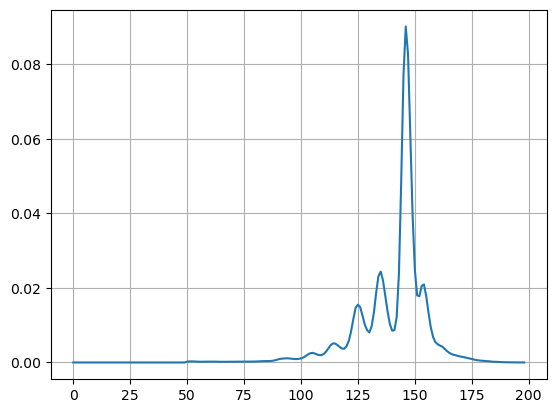

In [8]:
plt.plot(np.arange(len(hist)), hist)
plt.grid()

In [1786]:
exo_model = ExoModel(146, 0.1)

In [1790]:
exo_model.fit(hist)

ExoModel(l0=146, reg_koef=0.1)

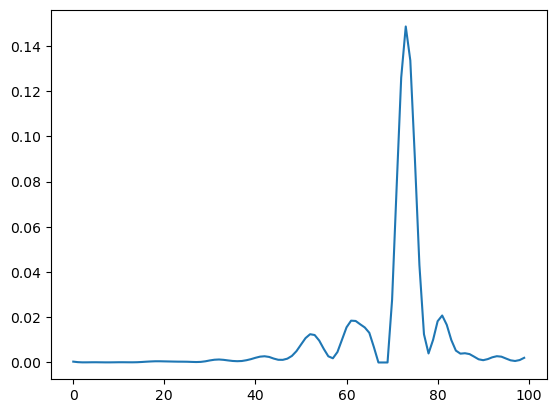

In [1792]:
x = exo_model.optimization_.x
plt.plot(x)

In [1793]:
np.argmax(x)

np.int64(73)

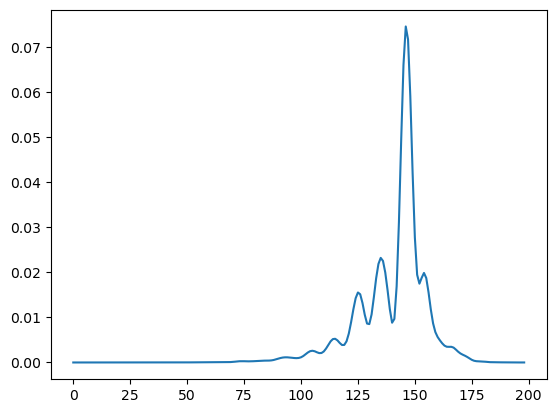

In [1794]:
plt.plot(np.convolve(x, x))

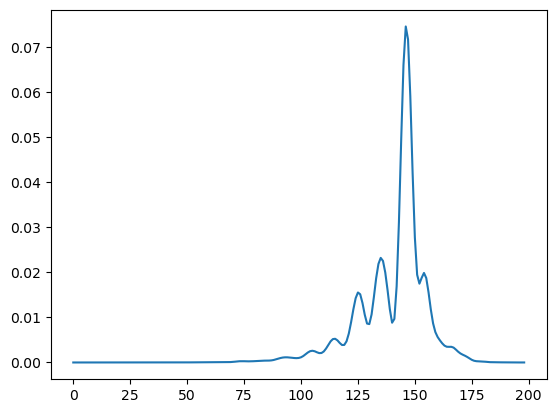

In [1795]:
plt.plot(np.convolve(x, x))

In [1796]:
class PysamRecordsDataset(Dataset):
    def __init__(self, pysam_records):
        self.records = self._collect_paired_reads(pysam_records)
        self.chromosome = pysam_records[0].reference_name

    def __getitem__(self, idx: int):
        record = self.records[idx]
        items = {
            "start": record[0].reference_start,
            "end": record[1].reference_end,
            "id": record[0].qname,
            "chromo": record[0].reference_name,
        }
        return items

    def __len__(self):
        return len(self.records)

    def _collect_paired_reads(self, records):
        read_pairs = defaultdict(dict)
        valid_pairs = []

        for read in records:
            name = read.query_name
            if read.is_read1:
                read_pairs[name]["R1"] = read
            elif read.is_read2:
                read_pairs[name]["R2"] = read

        # Отбираем только полные пары
        for name, pair in read_pairs.items():
            if "R1" in pair and "R2" in pair:
                valid_pairs.append((pair["R1"], pair["R2"]))

        return valid_pairs

In [1797]:
chrom_lengths = dict(zip(BAM_FILE.references, BAM_FILE.lengths))
chrom_lengths

{'NC_001133.9': 230218,
 'NC_001134.8': 813184,
 'NC_001135.5': 316620,
 'NC_001136.10': 1531933,
 'NC_001137.3': 576874,
 'NC_001138.5': 270161,
 'NC_001139.9': 1090940,
 'NC_001140.6': 562643,
 'NC_001141.2': 439888,
 'NC_001142.9': 745751,
 'NC_001143.9': 666816,
 'NC_001144.5': 1078177,
 'NC_001145.3': 924431,
 'NC_001146.8': 784333,
 'NC_001147.6': 1091291,
 'NC_001148.4': 948066,
 'NC_001224.1': 85779}

In [4015]:
records = list(BAM_FILE.fetch("NC_001136.10", 10000, 15000))

In [4016]:
templates = PysamRecordsDataset(records)

In [4017]:
loader = DataLoader(templates, 3000, False)

In [4018]:
templates = next(iter(loader))

In [4019]:
errors = torch.tensor(exo_model.optimization_.x)

In [4020]:
L = templates["start"].reshape(-1, 1)
R = templates["end"].reshape(-1, 1)

In [5140]:
class EMModel():
    def __init__(self, starts, stops, errors, n_initial, max_iter=500, reg_coef=0, tol=0.001, dyads=None, weights=None, device='cpu'):
        self.starts = self.__validate_cords(starts)
        self.stops = self.__validate_cords(stops)
        self.errors = errors
        self.n_initial = n_initial
        self.max_iter = max_iter
        self.dyads = self.__validate_dyads(dyads)
        self.weights = self.__validate_weights(weights)
        self.reg_coef = reg_coef
        self.tol = tol
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.Hij = None
        self.grid_probs = self.__create_grid_probs()
        self.device = device
        self.to(device)
        
    @property
    def nreads(self):
        return len(self.starts)
    
    @property
    def ndyads(self):
        return len(self.dyads)
        
    def __validate_cords(self, cords):
        return cords
    
    def __validate_dyads(self, dyads):
        if dyads is None:
            dyads = torch.linspace(self.starts.min(), self.stops.max(), self.n_initial).reshape(-1, 1)
        return dyads
    
    def __validate_weights(self, weights):
        if weights is None:
            weights = torch.rand(len(self.dyads), dtype=float).reshape(-1, 1)
            weights /= weights.sum()
        return weights
    
    def __create_probs_matrix(self, dyads):
        left_ones = (torch.ones((self.nreads, len(dyads)), dtype=float) * self.starts).T
        right_ones = (torch.ones((self.nreads, len(dyads)), dtype=float) * self.stops).T
        L_index = self.__insert_probs_to_matrix(dyads - left_ones, self.errors)
        R_index = self.__insert_probs_to_matrix(right_ones - dyads, self.errors)
        return (L_index * R_index).T
                      
    def __create_grid_probs(self):
        potential_dyads = torch.arange(self.starts.min(), self.stops.max(), 1).reshape(-1, 1)
        probs = torch.log(self.__create_probs_matrix(potential_dyads) + 1e-50)
        return probs
    
    def __insert_probs_to_matrix(self, idx_matrix, errors):
        valid_mask = (idx_matrix >= 0) & (idx_matrix < len(errors)).bool()
        idx_matrix[valid_mask] = errors[idx_matrix[valid_mask].int()]
        idx_matrix[~valid_mask] = 0
        return idx_matrix
                      
    def e_step(self):
        self.Hij = (self.probs_matrix * self.weights.T) / (self.probs_matrix @ self.weights)
                      
    def m_step(self):
        self.dyads = self.starts.min() + torch.argmax(self.grid_probs.T @ self.Hij, dim=0, keepdim=True).T
        self.weights = self.Hij.sum(0, keepdim=True).T
        self.weights = self.weights / self.weights.sum() - self.reg_coef
        self.weights[self.weights < 0] = 0
        self.weights /= self.weights.sum()
        if (self.weights == 0).all():
            raise ValueError("all weights = 0. It seems reg_coef is too high")
        
    def run(self):
        """Безопасная версия без сравнения тензоров разного размера"""
        cold_iter = 20

        for i in range(self.max_iter):
            # Всегда выполняем E и M шаги
            self.e_step()
            self.m_step()

            # Удаление после cold start
            if i > cold_iter:
                self.__delete_components()

    def __delete_components(self):
        keep_alive_mask = (self.weights > 0).bool().reshape(-1, 1)
        self.weights =  self.weights[keep_alive_mask].reshape(-1, 1)
        self.weights /= self.weights.sum()
        self.dyads = self.dyads[keep_alive_mask].reshape(-1, 1)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        
    def to(self, device):
        """Move model to specified device"""
        self.device = device
        self.starts = self.starts.to(device)
        self.stops = self.stops.to(device)
        self.errors = self.errors.to(device)
        self.dyads = self.dyads.to(device)
        self.weights = self.weights.to(device)
        if self.probs_matrix is not None:
            self.probs_matrix = self.probs_matrix.to(device)
        if self.Hij is not None:
            self.Hij = self.Hij.to(device)
            
    def get_params(self):
        params = {"L": self.starts,
                 "R": self.stops,
                 "errors": self.errors,
                 "n_initial": self.n_initial,
                 'max_iter': self.max_iter,
                 'reg_coef': self.reg_coef,
                 'tol': self.tol,
                 'dyads': self.dyads,
                 'weights': self.weights,
                 'device': self.device}
        return params

In [5145]:
model = EMModel(L, R, errors, 340, reg_coef=0.0002, max_iter=200, device="cpu")

In [5146]:
model.run()

In [5147]:
len(model.weights)

247

In [5148]:
def simple_reg_coef_search(search_max_iter=30, *args, **kwargs):
    """
    Упрощенный поиск reg_coef с возвратом оптимального значения.
    """
    low, high = 0.0, 0.1
    best_model = EMModel(*args, **kwargs)
    best_reg_coef = 0.0
    
    for i in range(search_max_iter):
        mid = (low + high) / 2
        model = EMModel(*args, **kwargs)
        model.reg_coef = mid
        
        try:
            model.run()

        except ValueError:
            high = mid
            continue
        else:
            if len(model.weights) < len(best_model.weights):
                best_model = model
            best_reg_coef = mid
            low = mid

        # Ранняя остановка при малом интервале
        if high - low < 1e-6:
            break
    
    return best_model, best_reg_coef

In [5149]:
m, c = simple_reg_coef_search(40, L, R, errors, 350, max_iter=300, device="cpu")

In [5150]:
model = m

<Axes: ylabel='Count'>

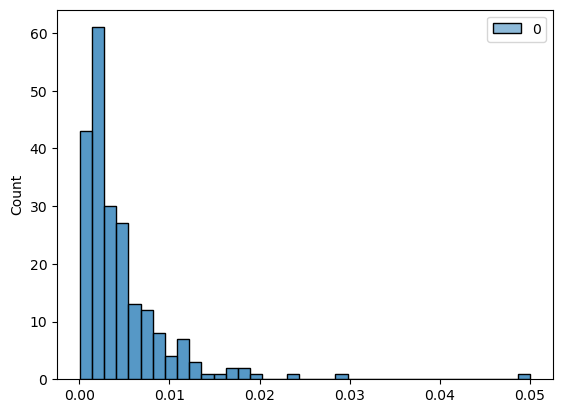

In [5152]:
counter = Counter()

for d, w in zip(model.dyads.flatten().numpy(), model.weights.flatten().numpy()):
    counter[int(d)] += float(w)

In [5153]:
x = np.arange(model.starts.min().numpy(), model.stops.max().numpy() + 1)
bars = [counter[i] for i in x]

In [5154]:
def make_occupancy(starts, stops):
    min_value = starts.min()
    max_value = stops.max()
    x = np.arange(min_value, max_value + 1)
    occ = np.zeros_like(x)
    for start, stop in zip(starts, stops):
        occ[start - min_value : stop - min_value + 1] += 1
    return x, occ


def make_template_occupancy(dyads, template):
    min_value = dyads.min()
    max_value = dyads.max()
    x = np.arange(min_value - len(template), max_value + 1 + len(template), dtype=float)
    occ = np.zeros_like(x)
    for dyad in dyads:
        start_pos = dyad - len(template) // 2 - min_value + len(template)
        occ[start_pos : start_pos + len(template)] += template
    return x, occ

In [5155]:
model_dyads = model.dyads.flatten().numpy()
model_weights = model.weights.flatten().numpy()
reads_labels = model.Hij.argmax(1)

In [5239]:
quantile = np.quantile(model_weights, 0.5)

mask = model_weights > quantile

allowed_labels = np.arange(len(mask))[mask]
reads_mask = np.isin(reads_labels, allowed_labels)
reads_filtered = reads_labels[reads_mask]
reads_dyads = model_dyads[reads_filtered]


weights_filtered = model_weights[mask]
dyads_filtered = model_dyads[mask]

In [5242]:
c = Counter(reads_dyads.tolist())
bars = [c[i] for i in x]

In [5244]:
x, occ = make_occupancy(L.numpy().flatten(), R.numpy().flatten())
template_x, templates_occ = make_template_occupancy(reads_dyads, exo_template.nuc_template)

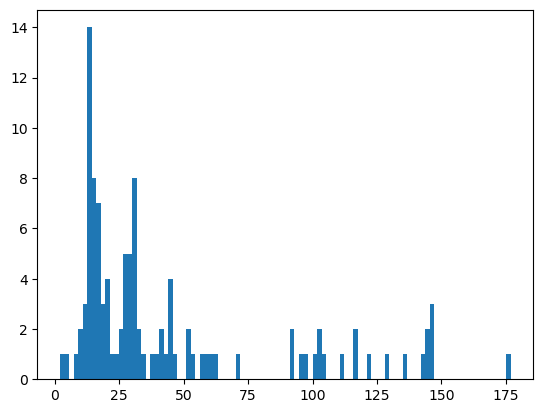

In [5227]:
_ = plt.hist(np.diff(sorted(dyads_filtered)), bins=100)

In [5346]:
df = pd.DataFrame({"start": L.flatten(), "stop": R.flatten()})
df["dyads"] = model.dyads[model.Hij.argmax(1)]
df["center"] = (df.start + df.stop) // 2
df['dyad_prob'] = model.weights[model.Hij.argmax(1)]

In [5369]:
q = np.quantile(df.dyad_prob, 0.25)

In [5378]:
df_filtered = df.query("dyad_prob > @q")

In [5379]:
reads_dyads = df_filtered.dyads.to_numpy()

In [5380]:
reads_dyads

array([10056, 10070, 10070, ..., 14869, 14869, 14869], shape=(1785,))

In [5381]:
x, occ = make_occupancy(L.numpy().flatten(), R.numpy().flatten())
template_x, templates_occ = make_template_occupancy(reads_dyads, exo_template.nuc_template)

c = Counter(df_filtered.dyads.values)
bars = [c[i] for i in x]

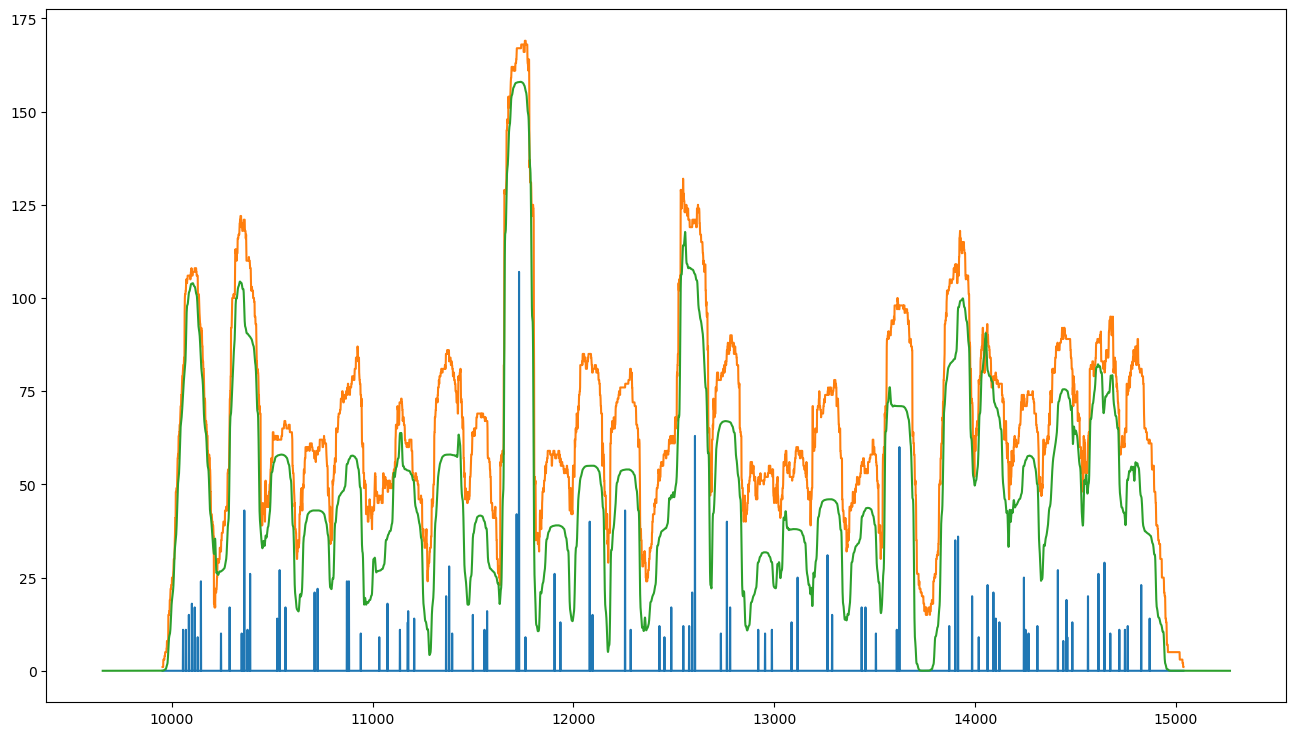

In [5382]:
plt.figure(figsize=(16, 9))
_ = plt.plot(x, bars)
plt.plot(x, occ)
plt.plot(template_x, templates_occ)


# plt.xlim(10000, 11000)

In [5383]:
df_filtered

,start,stop,dyads,center,dyad_prob
5,9974,10121,10056,10047,0.004607
6,9976,10142,10070,10059,0.004373
7,9976,10142,10070,10059,0.004373
8,9983,10129,10056,10056,0.004607
9,9983,10135,10056,10059,0.004607
...,...,...,...,...,...
2376,14804,14929,14869,14866,0.006278
2377,14804,14950,14869,14877,0.006278
2378,14806,14939,14869,14872,0.006278
2383,14812,14959,14869,14885,0.006278
